In [1]:
import PyMoosh as pm
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.linalg import toeplitz, inv

In [2]:
# Path to the modules folder
module_path = os.path.abspath(os.path.join('/home/chardon-grossard/Bureau/SWAG-P/Gap_Plasmon_2D/Workspace/', 'modules'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Path Workspace
workspace_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if workspace_dir not in sys.path:
    sys.path.append(workspace_dir)

# Définir le chemin absolu vers le dossier tools
tools_path = os.path.abspath(os.path.join(os.getcwd(), "..", "tools"))
if tools_path not in sys.path:
    sys.path.append(tools_path)

notebooks_dir = os.path.join(workspace_dir, "notebooks")
if notebooks_dir not in sys.path:
    sys.path.append(notebooks_dir)

summary_dir = os.path.join(notebooks_dir, "Summary_Simulation")
if summary_dir not in sys.path:
    sys.path.append(summary_dir)



# Path Data
data_dir = os.path.join(workspace_dir, "data")
ITO_path = os.path.join('/home/chardon-grossard/Bureau/SWAG-P/Gap_Plasmon_2D/Workspace/data', "ITO.txt")

json_combined_path = os.path.join(data_dir, "combined_materials.json")    

In [3]:
def faddeeva(z,N):
    "Bidouille les signes et les parties réelles et imaginaires d'un nombre complexe --> à creuser"
    w=np.zeros(z.size,dtype=complex)

    idx=np.real(z)==0
    w[idx]=np.exp(np.abs(-z[idx]**2))*(1-erf(np.imag(z[idx])))
    idx=np.invert(idx)
    idx1=idx + np.imag(z)<0

    z[idx1]=np.conj(z[idx1])

    M=2*N
    M2=2*M
    k = np.arange(-M+1,M)
    L=np.sqrt(N/np.sqrt(2))

    theta=k*np.pi/M
    t=L*np.tan(theta/2)
    f=np.exp(-t**2)*(L**2+t**2)
    f=np.append(0,f)
    a=np.real(np.fft.fft(np.fft.fftshift(f)))/M2
    a=np.flipud(a[1:N+1])

    Z=(L+1.0j*z[idx])/(L-1.0j*z[idx])
    p=np.polyval(a,Z)
    w[idx]=2*p/(L-1.0j*z[idx])**2+(1/np.sqrt(np.pi))/(L-1.0j*z[idx])
    w[idx1]=np.conj(2*np.exp(-z[idx1]**2) - w[idx1])
    return(w)

In [4]:
def epsAlbb(lam):
    "Permet de caluler la permittivité de l'argent en une longueur d'onde lam donnée"
    w=6.62606957e-25*299792458/1.602176565e-19/lam
    f0=0.526
    Gamma0=0.047
    omega_p=14.98
    f=np.array([0.213,0.060,0.182,0.014])
    Gamma=np.array([0.312,0.315,1.587,2.145])
    omega=np.array([0.163,1.561,1.827,4.495])
    sigma=np.array([0.013,0.042,0.256,1.735])
    a=np.sqrt(w*(w+1.0j*Gamma))
    a=a*np.sign(np.real(a))
    x=(a-omega)/(np.sqrt(2)*sigma)
    y=(a+omega)/(np.sqrt(2)*sigma)
    # Conversion
    aha=1.0j*np.sqrt(np.pi)*f*omega_p**2/(2*np.sqrt(2)*a*sigma)*(faddeeva(x,64)+faddeeva(y,64))
    epsilon=1-omega_p**2*f0/(w*(w+1.0j*Gamma0))+np.sum(aha)
    return(epsilon)




def epsAgbb(lam):
    "Permet de caluler la permittivité de l'argent en une longueur d'onde lam donnée"
    w=6.62606957e-25*299792458/1.602176565e-19/lam
    f0=0.821
    Gamma0=0.049
    omega_p=9.01
    f=np.array([0.050,0.133,0.051,0.467,4.000])
    Gamma=np.array([0.189,0.067,0.019,0.117,0.052])
    omega=np.array([2.025,5.185,4.343,9.809,18.56])
    sigma=np.array([1.894,0.665,0.189,1.170,0.516])
    a=np.sqrt(w*(w+1.0j*Gamma))
    a=a*np.sign(np.real(a))
    x=(a-omega)/(np.sqrt(2)*sigma)
    y=(a+omega)/(np.sqrt(2)*sigma)
    # Conversion
    aha=1.0j*np.sqrt(np.pi)*f*omega_p**2/(2*np.sqrt(2)*a*sigma)*(faddeeva(x,64)+faddeeva(y,64))
    epsilon=1-omega_p**2*f0/(w*(w+1.0j*Gamma0))+np.sum(aha)
    return(epsilon)



def nk_ITO(lam):
    tableau3D = []
    
    # Utilisation d'un gestionnaire de contexte pour ouvrir le fichier
    with open(ITO_path, "r") as file:
        lines = file.readlines()
    
    nb_lines = len(lines)
    for idx in range(2, nb_lines - 2):
        # On enlève les espaces superflus et on split la ligne par tabulation
        values = lines[idx].strip().split("\t")
        try:
            values = [float(val) for val in values]
        except ValueError:
            continue  # En cas d'erreur de conversion, on ignore la ligne
        tableau3D.append(values)
    
    tableau3D = np.array(tableau3D)
    # Extraction des colonnes : première colonne = longueur d'onde, deuxième = n, troisième = k
    wl = tableau3D[:, 0] * 1000 

    n = tableau3D[:, 1]
    k = tableau3D[:, 2]

    # Interpolation pour obtenir n et k à la longueur d'onde lam
    n_int = np.interp(lam, wl, n)
    k_int = np.interp(lam, wl, k)

    ri = n_int + 1.0j * k_int
    return (n_int, k_int, ri)


In [5]:
# On définit uniquement la plage de longueurs d'onde
list_wavelength = np.linspace(450, 1000, 200)

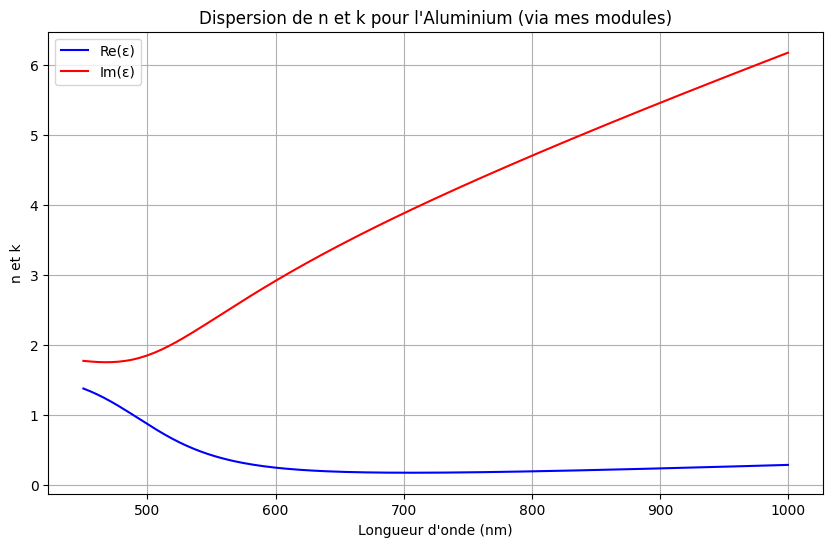

In [8]:
from Functions_Models_Data import get_material_permittivity


# Définition d'une plage de longueurs d'onde en nm
lambda_range = np.linspace(450, 1000, 200)

# Calcul de la permittivité pour Al à chaque longueur d'onde
epsilon_vals = []
for lam in lambda_range:
    # get_material_permittivity retourne ε à la longueur d'onde lam
    eps_val = get_material_permittivity("Gold", lam, json_combined_path, data_dir)
    epsilon_vals.append(eps_val)
epsilon_vals = np.array(epsilon_vals)

# On considère que ε = (n + 1j*k)², donc pour obtenir n et k,
# on prend la racine carrée de ε.

# Tracé des parties réelle et imaginaire
plt.figure(figsize=(10, 6))
plt.plot(list_wavelength, np.real(np.sqrt(epsilon_vals)), label='Re(ε)', color='blue')
plt.plot(list_wavelength, np.imag(np.sqrt(epsilon_vals)), label='Im(ε)', color='red')
plt.xlabel("Longueur d'onde (nm)")
plt.ylabel("n et k")
plt.title("Dispersion de n et k pour l'Aluminium (via mes modules)")
plt.legend()
plt.grid(True)
plt.show()


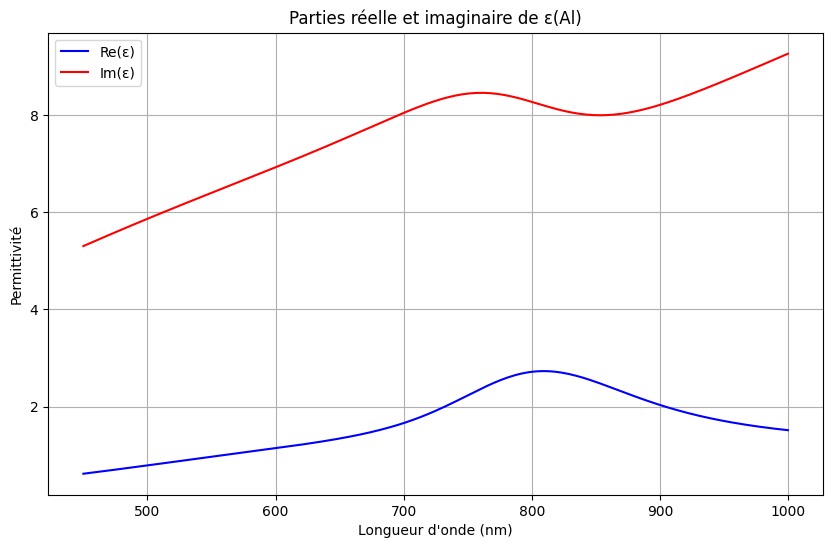

In [7]:
# Calcul de ε pour chaque longueur d'onde
epsilon_valuesAl = np.array([epsAlbb(lam) for lam in list_wavelength])

# Tracé des parties réelle et imaginaire de ε
plt.figure(figsize=(10, 6))


plt.plot(list_wavelength, np.real(np.sqrt(epsilon_valuesAl)), label='Re(ε)', color='blue')
plt.plot(list_wavelength, np.imag(np.sqrt(epsilon_valuesAl)), label='Im(ε)', color='red')

plt.xlabel("Longueur d'onde (nm)")
plt.ylabel("Permittivité")
plt.title("Parties réelle et imaginaire de ε(Al)")
plt.legend()
plt.grid(True)
plt.show()